In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tqdm import tqdm


In [3]:
df = pd.read_csv(Path.home() / "proteina/inference/inference_seq_cond_sampling_ca_dssp_beta-2.5-2.0_finetune-all_v1.6_default-fold_21-seq-S25_128-eff-bs_purge-test_warmup_cutoff-190828_last_045-noise/af2rank_on_proteinebm_top_k_cross_protein_analysis/af2rank_on_proteinebm_top_5_summary.csv")
print(df.columns)
df.head()


Index(['protein_id', 'reference_tm', 'in_train', 'length', 'top_k',
       'min_energy_topk', 'max_ptm_topk', 'm2_max_ptm_topk',
       'min_max_ptm_topk', 'm1_top_1_ptm', 'm1_top_1_tm_ref_pred',
       'm1_top_1_composite', 'm1_top_1_plddt', 'm1_top_5_ptm',
       'm1_top_5_tm_ref_pred', 'm1_top_5_composite', 'm1_top_5_plddt',
       'm2_top_1_ptm', 'm2_top_1_tm_ref_pred', 'm2_top_1_composite',
       'm2_top_1_plddt', 'm2_top_5_ptm', 'm2_top_5_tm_ref_pred',
       'm2_top_5_composite', 'm2_top_5_plddt', 'min_top_1_ptm',
       'min_top_1_tm_ref_pred', 'min_top_1_composite', 'min_top_1_plddt',
       'min_top_5_ptm', 'min_top_5_tm_ref_pred', 'min_top_5_composite',
       'min_top_5_plddt', 'top_1_ptm', 'top_1_tm_ref_pred', 'top_1_composite',
       'top_1_plddt', 'top_5_ptm', 'top_5_tm_ref_pred', 'top_5_composite',
       'top_5_plddt', 'proteinebm_scores_csv', 'af2rank_scores_csv'],
      dtype='object')


,protein_id,reference_tm,in_train,length,top_k,min_energy_topk,max_ptm_topk,m2_max_ptm_topk,min_max_ptm_topk,m1_top_1_ptm,...,top_1_ptm,top_1_tm_ref_pred,top_1_composite,top_1_plddt,top_5_ptm,top_5_tm_ref_pred,top_5_composite,top_5_plddt,proteinebm_scores_csv,af2rank_scores_csv
0,6UF2_A,0.4655,False,124.0,5,3773.386719,0.489511,0.519681,0.481501,0.489511,...,0.489511,0.38259,0.262310,0.535861,0.481279,0.41292,0.254365,0.528520,/home/ubuntu/proteina/inference/inference_seq_...,/home/ubuntu/proteina/inference/inference_seq_...
1,6ZVY_A,0.4520,False,290.0,5,9377.792969,0.708889,0.695037,0.695037,0.708889,...,0.708889,0.72577,0.460355,0.649403,0.698573,0.73011,0.446916,0.639755,/home/ubuntu/proteina/inference/inference_seq_...,/home/ubuntu/proteina/inference/inference_seq_...
2,7A2D_A,0.4592,False,171.0,5,5651.122070,0.635651,0.549106,0.549106,0.635651,...,0.635651,0.44298,0.439516,0.691442,0.635651,0.44298,0.439516,0.691442,/home/ubuntu/proteina/inference/inference_seq_...,/home/ubuntu/proteina/inference/inference_seq_...
3,7ZIX_A,0.4520,False,290.0,5,9418.523438,0.677336,0.686206,0.677336,0.677336,...,0.677336,0.73417,0.417434,0.616287,0.677336,0.73417,0.417434,0.616287,/home/ubuntu/proteina/inference/inference_seq_...,/home/ubuntu/proteina/inference/inference_seq_...
4,8AUC_B,0.3043,False,492.0,5,16292.238281,0.478105,0.549428,0.478105,0.478105,...,0.478105,0.15653,0.298366,0.624060,0.395801,0.34531,0.263219,0.665029,/home/ubuntu/proteina/inference/inference_seq_...,/home/ubuntu/proteina/inference/inference_seq_...


['6U1O_A' '7MQQ_A' '7VZM_A' '7DME_A' '8XHT_A']
   protein_id  min_top_1_ptm  top_1_tm_ref_pred
14     6U1O_A       0.697508            0.21080
17     7MQQ_A       0.604596            0.20120
24     7VZM_A       0.693330            0.19223
30     7DME_A       0.639912            0.24888
31     8XHT_A       0.758880            0.25495


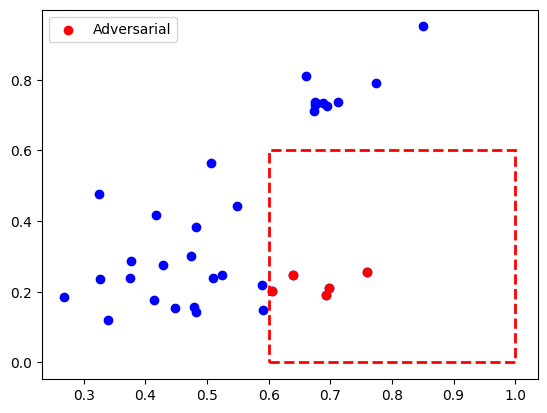

In [4]:
adv_df = df[np.logical_and(df["min_top_1_ptm"] > 0.6, df["top_1_tm_ref_pred"] < 0.6)]
adv_id_list = adv_df["protein_id"].unique()

print(adv_id_list)
print(adv_df[["protein_id", "min_top_1_ptm", "top_1_tm_ref_pred"]])

plt.scatter(df["min_top_1_ptm"], df["top_1_tm_ref_pred"], c="blue")
plt.scatter(adv_df["min_top_1_ptm"], adv_df["top_1_tm_ref_pred"], c="red", label="Adversarial")

# Draw a red box around (0.6, 0.6) and (1.0, 0.0)
current_ax = plt.gca()
# Rectangle: lower left is (0.6, 0.0), width is 1.0-0.6=0.4, height is 0.6-0.0=0.6
rect = Rectangle((0.6, 0.0), 0.4, 0.6, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
current_ax.add_patch(rect)

plt.legend()
plt.show()


In [5]:
import zipfile

# Recursively zip the inference results subdirectories (preserving directory structure under each protein_id)
base_dir = Path.home() / "proteina/inference/inference_seq_cond_sampling_ca_dssp_beta-2.5-2.0_finetune-all_v1.6_default-fold_21-seq-S25_128-eff-bs_purge-test_warmup_cutoff-190828_last_045-noise"
for protein_id in tqdm(adv_id_list):
    protein_dir = base_dir / protein_id
    if protein_dir.exists():
        # Create the zip file outside the protein_dir to avoid including it in itself
        zip_file = base_dir / f"{protein_id}.zip"
        with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED, allowZip64=True) as zipf:
            for f in protein_dir.rglob("*"):
                if f != zip_file and f.is_file():
                    # arcname ensures top-level protein_id directory in archive
                    zipf.write(f, arcname=f"{protein_id}/{f.relative_to(protein_dir)}")


100%|██████████| 5/5 [00:01<00:00,  2.78it/s]


In [6]:
failed_afdb_df = pd.read_csv(Path.home() / "data/bad_afdb/pdb_70_cluster_reps_aligned_confidence_aggregate_monomer_length_50-640_tm-05_coverage-08_identity-07_cutoff-190828_in-train.csv")
print(failed_afdb_df.columns)
adv_pdb_to_uniprot = {row["protein_id"]: failed_afdb_df[failed_afdb_df["pdb"] == row["protein_id"]]["uniprot"].values[0] for _, row in adv_df.iterrows()}
print(adv_pdb_to_uniprot)


Index(['pdb', 'uniprot', 'identity', 'plddt', 'coverage', 'length',
       'stoichiometry', 'oligomeric_state', 'full_composition', 'tm_score',
       'in_train'],
      dtype='object')
{'6U1O_A': 'P25637', '7MQQ_A': 'A0A5B0MRS6', '7VZM_A': 'A0A1A9KGY0', '7DME_A': 'O95433', '8XHT_A': 'A0A241XEQ7'}
